# Module 8 — Evaluation Metrics

## Metrics explained

### PSNR — Peak Signal-to-Noise Ratio
$$\text{PSNR} = 10 \cdot \log_{10}\!\left(\frac{255^2}{\text{MSE}}\right)$$

- Measured in **dB** — higher is better
- > 30 dB is generally acceptable for enhancement
- > 40 dB is considered high quality
- Measures pixel-level error only (doesn't match human perception well)

### SSIM — Structural Similarity Index
$$\text{SSIM}(x, y) = [l(x,y)]^\alpha \cdot [c(x,y)]^\beta \cdot [s(x,y)]^\gamma$$

- Range **[0, 1]** — higher is better (1 = identical)
- Combines **luminance** × **contrast** × **structure**
- Correlates much better with **human visual perception** than PSNR


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

from config import Config
from enhancer import ImageEnhancer

print("Imports successful.")

Imports successful.


In [15]:
#metric functions

def compute_psnr(img1: np.ndarray, img2: np.ndarray) -> float:
    """
    Peak Signal-to-Noise Ratio in dB.
    Higher is better. Inputs: grayscale uint8 arrays, same shape.
    """
    if img1.ndim == 3:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    if img2.ndim == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    return float(psnr_fn(img1, img2, data_range=255))


def compute_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    """
    Structural Similarity Index in [0, 1]. Higher is better.
    """
    if img1.ndim == 3:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    if img2.ndim == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    return float(ssim_fn(img1, img2, data_range=255))


def evaluate_enhancement(original:   np.ndarray,
                          fuzzy_only: np.ndarray,
                          cnn_fuzzy:  np.ndarray) -> dict:
    """
    Compare fuzzy-only vs CNN+Fuzzy against the original (reference).

    Returns dict with PSNR and SSIM for both methods, plus report string.
    """
    psnr_fuzzy = compute_psnr(original, fuzzy_only)
    psnr_cnn   = compute_psnr(original, cnn_fuzzy)
    ssim_fuzzy = compute_ssim(original, fuzzy_only)
    ssim_cnn   = compute_ssim(original, cnn_fuzzy)

    winner_psnr = "CNN+Fuzzy" if psnr_cnn > psnr_fuzzy else "Fuzzy only"
    winner_ssim = "CNN+Fuzzy" if ssim_cnn > ssim_fuzzy else "Fuzzy only"

    report = (
        "\n"
        "IMAGE ENHANCEMENT EVALUATION\n"
        f" Method │  PSNR (dB) │ SSIM\n"
        f"Fuzzy only{psnr_fuzzy:8.3f} | {ssim_fuzzy:.5f}\n"
        f"CNN + Fuzzy{psnr_cnn:8.3f} | {ssim_cnn:.5f}\n"
        f"Best PSNR: {winner_psnr:<10s}\n"
        f"Best SSIM: {winner_ssim:<10s}\n"
    )
    print(report)

    return {
        "psnr_fuzzy": psnr_fuzzy,
        "psnr_cnn":   psnr_cnn,
        "ssim_fuzzy": ssim_fuzzy,
        "ssim_cnn":   ssim_cnn,
        "report":     report,
    }


print("Metric functions defined.")

Metric functions defined.


In [16]:
#Load test image and run enhancement
import os

if os.path.exists(Config.SAMPLE_IMAGE):
    original = cv2.imread(Config.SAMPLE_IMAGE)
    original = cv2.resize(original, Config.IMAGE_SIZE)
else:
    np.random.seed(7)
    base     = np.random.randint(20, 90, (*Config.IMAGE_SIZE, 3), dtype=np.uint8)
    original = cv2.GaussianBlur(base, (9, 9), 0)

enhancer       = ImageEnhancer()
cnn_fuzzy_img, info  = enhancer.enhance(original)
fuzzy_only_img, _    = enhancer.enhance_fuzzy_only(original)

print("Images ready.")

[Enhancer] CNN loaded from 'cnn_enhancer.pth'
[Enhancer] Fuzzy system initialised.
Images ready.


In [17]:
# Run full evaluation 

metrics = evaluate_enhancement(original, fuzzy_only_img, cnn_fuzzy_img)


IMAGE ENHANCEMENT EVALUATION
 Method │  PSNR (dB) │ SSIM
Fuzzy only  24.263 | 0.73505
CNN + Fuzzy  14.064 | 0.37393
Best PSNR: Fuzzy only
Best SSIM: Fuzzy only



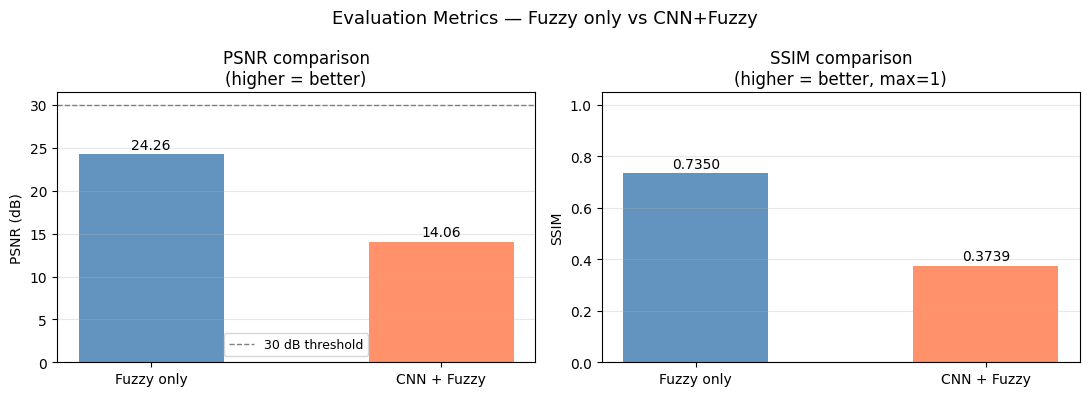

Saved evaluation_metrics.png


In [20]:
# Visualise metrics comparison

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

methods = ["Fuzzy only", "CNN + Fuzzy"]
colors  = ["steelblue", "coral"]

# PSNR bar chart
psnr_vals = [metrics["psnr_fuzzy"], metrics["psnr_cnn"]]
bars1 = ax1.bar(methods, psnr_vals, color=colors, alpha=0.85, width=0.5)
ax1.set_ylabel("PSNR (dB)")
ax1.set_title("PSNR comparison\n(higher = better)")
ax1.axhline(30, color="gray", linewidth=1, linestyle="--", label="30 dB threshold")
ax1.legend(fontsize=9)
ax1.grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, psnr_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.2f}", ha="center", va="bottom", fontsize=10)

# SSIM bar chart
ssim_vals = [metrics["ssim_fuzzy"], metrics["ssim_cnn"]]
bars2 = ax2.bar(methods, ssim_vals, color=colors, alpha=0.85, width=0.5)
ax2.set_ylabel("SSIM")
ax2.set_title("SSIM comparison\n(higher = better, max=1)")
ax2.set_ylim(0, 1.05)
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, ssim_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Evaluation Metrics — Fuzzy only vs CNN+Fuzzy", fontsize=13)
plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=120)
plt.show()
print("Saved evaluation_metrics.png")

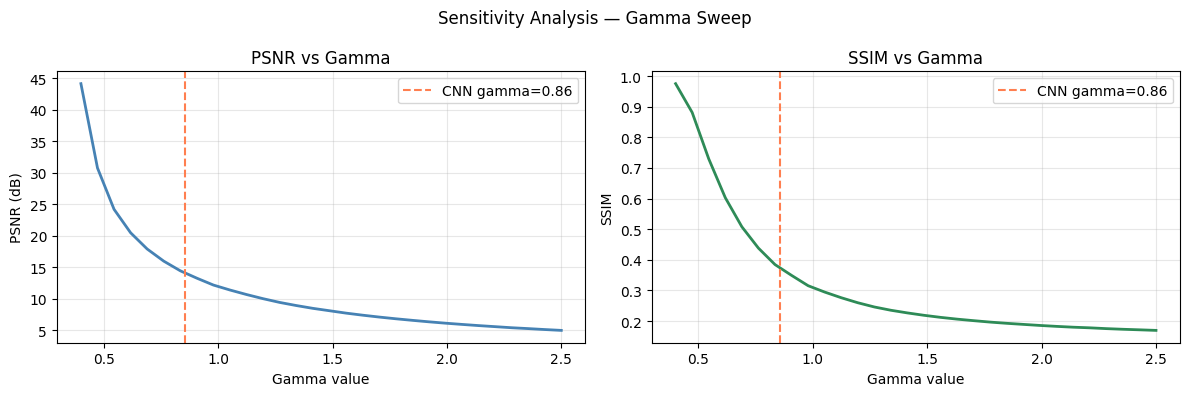

Saved gamma_sensitivity.png


In [22]:
# PSNR sensitivity analysis: effect of gamma 

from enhancer import apply_enhancement

gamma_range  = np.linspace(0.4, 2.5, 30)
psnr_results = []
ssim_results = []

for g in gamma_range:
    enhanced = apply_enhancement(original,
                                 brightness_factor=info["brightness_factor"],
                                 contrast_factor=info["contrast_factor"],
                                 gamma=g)
    psnr_results.append(compute_psnr(original, enhanced))
    ssim_results.append(compute_ssim(original, enhanced))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(gamma_range, psnr_results, color="steelblue", linewidth=2)
ax1.set_xlabel("Gamma value")
ax1.set_ylabel("PSNR (dB)")
ax1.set_title("PSNR vs Gamma")
ax1.axvline(info["gamma"], color="coral", linestyle="--", label=f"CNN gamma={info['gamma']:.2f}")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(gamma_range, ssim_results, color="seagreen", linewidth=2)
ax2.set_xlabel("Gamma value")
ax2.set_ylabel("SSIM")
ax2.set_title("SSIM vs Gamma")
ax2.axvline(info["gamma"], color="coral", linestyle="--", label=f"CNN gamma={info['gamma']:.2f}")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("Sensitivity Analysis — Gamma Sweep", fontsize=12)
plt.tight_layout()
plt.savefig("gamma_sensitivity.png", dpi=120)
plt.show()
print("Saved gamma_sensitivity.png")

In [26]:
#Save module to disk
import inspect

source = """
import cv2, numpy as np
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

def compute_psnr(img1: np.ndarray, img2: np.ndarray) -> float:
    
    if img1.ndim == 3:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    if img2.ndim == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    return float(psnr_fn(img1, img2, data_range=255))


def compute_ssim(img1: np.ndarray, img2: np.ndarray) -> float:
    
    if img1.ndim == 3:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    if img2.ndim == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    return float(ssim_fn(img1, img2, data_range=255))


def evaluate_enhancement(original:   np.ndarray,
                          fuzzy_only: np.ndarray,
                          cnn_fuzzy:  np.ndarray) -> dict:
    
    psnr_fuzzy = compute_psnr(original, fuzzy_only)
    psnr_cnn   = compute_psnr(original, cnn_fuzzy)
    ssim_fuzzy = compute_ssim(original, fuzzy_only)
    ssim_cnn   = compute_ssim(original, cnn_fuzzy)

    winner_psnr = "CNN+Fuzzy" if psnr_cnn > psnr_fuzzy else "Fuzzy only"
    winner_ssim = "CNN+Fuzzy" if ssim_cnn > ssim_fuzzy else "Fuzzy only"

    report = (
        "\n"
        "IMAGE ENHANCEMENT EVALUATION\n"
        f" Method │  PSNR (dB) │ SSIM\n"
        f"Fuzzy only{psnr_fuzzy:8.3f} | {ssim_fuzzy:.5f}\n"
        f"CNN + Fuzzy{psnr_cnn:8.3f} | {ssim_cnn:.5f}\n"
        f"Best PSNR: {winner_psnr:<10s}\n"
        f"Best SSIM: {winner_ssim:<10s}\n"
    )
    print(report)

    return {
        "psnr_fuzzy": psnr_fuzzy,
        "psnr_cnn":   psnr_cnn,
        "ssim_fuzzy": ssim_fuzzy,
        "ssim_cnn":   ssim_cnn,
        "report":     report,
    }

"""

with open("evaluator.py", "w", encoding="utf-8") as f:
    f.write(source)

print("evaluator.py written to disk.")

evaluator.py written to disk.
